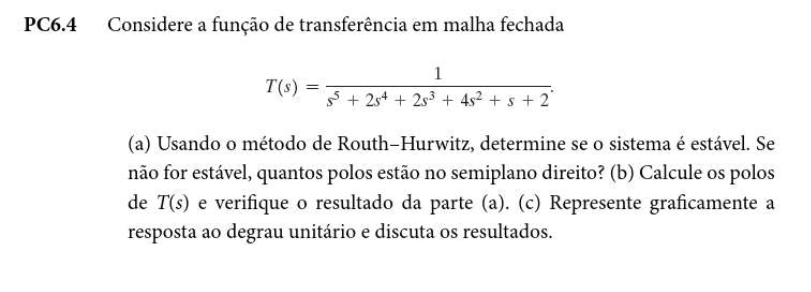

Linha s^3 é toda zero! Usando polinômio auxiliar.
Linha s^1 é toda zero! Usando polinômio auxiliar.

Tabela de Routh-Hurwitz:
[[1. 2. 1.]
 [2. 4. 2.]
 [8. 8. 0.]
 [2. 2. 0.]
 [4. 0. 0.]
 [2. 0. 0.]]

Mudanças de sinal na 1ª coluna: 0
Polos do sistema:
[-2.00000000e+00+0.j         -3.97581489e-09+1.00000002j
 -3.97581489e-09-1.00000002j  3.97581464e-09+0.99999998j
  3.97581464e-09-0.99999998j]
Linha s^3 é toda zero! Usando polinômio auxiliar.
Linha s^1 é toda zero! Usando polinômio auxiliar.

Tabela de Routh-Hurwitz:
[[1. 2. 1.]
 [2. 4. 2.]
 [8. 8. 0.]
 [2. 2. 0.]
 [4. 0. 0.]
 [2. 0. 0.]]

Mudanças de sinal na 1ª coluna: 0


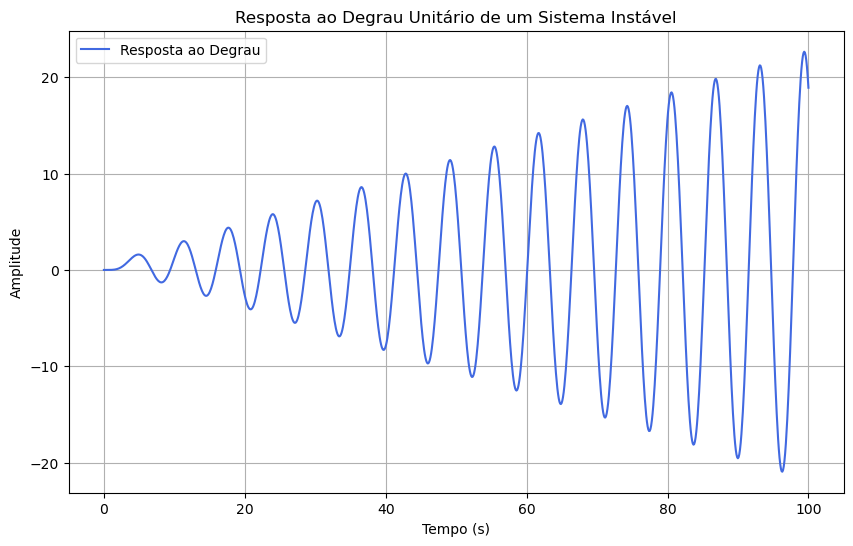

In [3]:
import control as ctrl
import matplotlib.pyplot as plt
import numpy as np

def routh_hurwitz(coeffs):
    # Determina o número de linhas
    n = len(coeffs)
    num_cols = (n + 1) // 2
    table = np.zeros((n, num_cols))

    # Preenche as duas primeiras linhas com os coeficientes do polinômio
    table[0, :len(coeffs[::2])] = coeffs[::2]
    table[1, :len(coeffs[1::2])] = coeffs[1::2]

    for i in range(2, n):
        for j in range(num_cols - 1):
            # Cálculo padrão de Routh: (b1*c1 - a1*d1) / b1
            if table[i-1, 0] != 0:
                table[i, j] = ((table[i-1, 0] * table[i-2, j+1]) - 
                               (table[i-2, 0] * table[i-1, j+1])) / table[i-1, 0]
        
        # Caso especial: Linha de zeros (indica polos simétricos/eixo imaginário)
        if np.all(table[i, :] == 0):
            print(f"Linha s^{n-i-1} é toda zero! Usando polinômio auxiliar.")
            # Coeficientes do polinômio auxiliar (linha acima)
            aux_power = n - i
            poly_aux = table[i-1, :((aux_power // 2) + 1)]
            # Derivada do polinômio auxiliar
            for k in range(len(poly_aux)):
                table[i, k] = poly_aux[k] * (aux_power - 2*k)

    return table

# Polinômio: s^5 + 2s^4 + 2s^3 + 4s^2 + s + 2
coeffs = [1, 2, 2, 4, 1, 2]
tabela = routh_hurwitz(coeffs)

print("\nTabela de Routh-Hurwitz:")
print(tabela)

# Verificação de trocas de sinal na primeira coluna
primeira_coluna = tabela[:, 0]
mudancas_sinal = np.sum(np.diff(np.sign(primeira_coluna)) != 0)

print(f"\nMudanças de sinal na 1ª coluna: {mudancas_sinal}")
if mudancas_sinal == 0 and any(np.roots(coeffs).real == 0):
    print("Resultado: Sistema Instável (polos repetidos no eixo imaginário).")

# Definindo a função de transferência T(s)
num = [1]
den = [1, 2, 2, 4, 1, 2]
T = ctrl.TransferFunction(num, den)

# (b) Calculando e exibindo os polos
polos = ctrl.poles(T)
print("Polos do sistema:")
print(polos)
import numpy as np
import control as ctrl

def routh_hurwitz(coeffs):
    # Determina o número de linhas
    n = len(coeffs)
    num_cols = (n + 1) // 2
    table = np.zeros((n, num_cols))

    # Preenche as duas primeiras linhas com os coeficientes do polinômio
    table[0, :len(coeffs[::2])] = coeffs[::2]
    table[1, :len(coeffs[1::2])] = coeffs[1::2]

    for i in range(2, n):
        for j in range(num_cols - 1):
            # Cálculo padrão de Routh: (b1*c1 - a1*d1) / b1
            if table[i-1, 0] != 0:
                table[i, j] = ((table[i-1, 0] * table[i-2, j+1]) - 
                               (table[i-2, 0] * table[i-1, j+1])) / table[i-1, 0]
        
        # Caso especial: Linha de zeros (indica polos simétricos/eixo imaginário)
        if np.all(table[i, :] == 0):
            print(f"Linha s^{n-i-1} é toda zero! Usando polinômio auxiliar.")
            # Coeficientes do polinômio auxiliar (linha acima)
            aux_power = n - i
            poly_aux = table[i-1, :((aux_power // 2) + 1)]
            # Derivada do polinômio auxiliar
            for k in range(len(poly_aux)):
                table[i, k] = poly_aux[k] * (aux_power - 2*k)

    return table

# Polinômio: s^5 + 2s^4 + 2s^3 + 4s^2 + s + 2
coeffs = [1, 2, 2, 4, 1, 2]
tabela = routh_hurwitz(coeffs)

print("\nTabela de Routh-Hurwitz:")
print(tabela)

# Verificação de trocas de sinal na primeira coluna
primeira_coluna = tabela[:, 0]
mudancas_sinal = np.sum(np.diff(np.sign(primeira_coluna)) != 0)

print(f"\nMudanças de sinal na 1ª coluna: {mudancas_sinal}")
if mudancas_sinal == 0 and any(np.roots(coeffs).real == 0):
    print("Resultado: Sistema Instável (polos repetidos no eixo imaginário).")
# (c) Simulando a resposta ao degrau unitário
t = np.linspace(0, 100, 1000)  # Tempo de simulação de 0 a 100s
t, y = ctrl.step_response(T, T=t)

# Plotando o gráfico
plt.figure(figsize=(10, 6))
plt.plot(t, y, label="Resposta ao Degrau", color="royalblue")
plt.title("Resposta ao Degrau Unitário de um Sistema Instável")
plt.xlabel("Tempo (s)")
plt.ylabel("Amplitude")
plt.grid(True)
plt.legend()
plt.show()